## Setup e carregamento dos dados

In [1]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield

# Carrega a coleção Cranfield. load_cranfield() usa ir_datasets e, se o
# download falhar, cai automaticamente nos arquivos originais em data/raw/.
# Os outros notebooks usam o mesmo loader, garantindo a mesma coleção em todos.
df_docs, df_queries, df_qrels = load_cranfield()

In [2]:
from src.pre_processing import (
    PREPROCESSING_CONFIGS,
    build_all_configs,
    vocabulary_stats,
    save_preprocessed,
)

## Análise exploratória das consultas

In [3]:
# Olha a estrutura dos DataFrames
display(df_queries.head())

# Tamanho (em palavras) das consultas, pra embasar a análise crítica no relatório
df_queries['words_length'] = df_queries['text'].apply(lambda x: len(x.split()))
display(df_queries['words_length'].describe())

,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...
2,3,what problems of heat conduction in composite ...
3,4,can a criterion be developed to show empirical...
4,5,what chemical kinetic system is applicable to ...


count    225.000000
mean      17.973333
std        7.131995
min        6.000000
25%       13.000000
50%       17.000000
75%       22.000000
max       46.000000
Name: words_length, dtype: float64

## Análise exploratória dos qrels (relevância)

In [4]:
# Distribuição dos graus de relevância no qrels
display(df_qrels['relevance'].value_counts())

# Cria a coluna 'is_relevant' (1 = relevante, 0 = não) a partir do grau de relevância
df_qrels['is_relevant'] = df_qrels['relevance'].apply(lambda x: 1 if x >= 1 else 0)

# Quantidade de documentos relevantes por consulta
relevantes_por_query = df_qrels[df_qrels['is_relevant'] == 1].groupby('query_id').size()
print("\nRelevant documents per query:")
display(relevantes_por_query.describe())

relevance
 3    734
 2    387
 4    363
-1    225
 1    128
Name: count, dtype: int64


Relevant documents per query:


count    225.000000
mean       7.164444
std        5.388031
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       39.000000
dtype: float64

In [5]:
# Consultas com 2 ou menos documentos relevantes
qrels_relevants = df_qrels[df_qrels['is_relevant'] == 1]

# Conta os documentos relevantes de cada consulta
relevants_count = qrels_relevants.groupby('query_id').size()

# Identifica as consultas com 2 ou menos documentos relevantes
dificult_queries = relevants_count[relevants_count <= 2]
print(f"Queries with 2 or fewer relevant documents: {len(dificult_queries)}")
display(dificult_queries.head())

Queries with 2 or fewer relevant documents: 35


query_id
103    2
112    2
117    2
119    1
123    2
dtype: int64

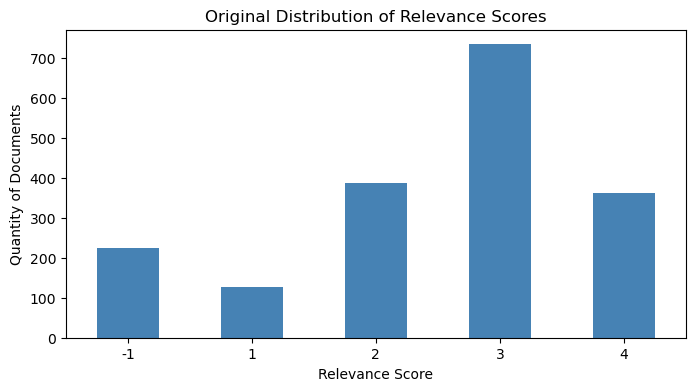

In [6]:
# Plota a distribuição original dos graus de relevância
df_qrels['relevance'].value_counts().sort_index().plot(
    kind='bar', 
    color='steelblue', 
    figsize=(8, 4),
    title='Original Distribution of Relevance Scores'
)
plt.xlabel('Relevance Score')
plt.ylabel('Quantity of Documents')
plt.xticks(rotation=0)
plt.show()

## Análise exploratória dos documentos

In [7]:
# Olha a estrutura do DataFrame de documentos
display(df_docs.isna().sum())

# Comprimento dos documentos, pra embasar a análise crítica no relatório
df_docs['text_length'] = df_docs['text'].apply(lambda x: len(str(x).split()))
print("\nStatistics of document lengths:")
display(df_docs['text_length'].describe())

doc_id    0
title     0
text      0
author    0
bib       0
dtype: int64


Statistics of document lengths:


count    1400.000000
mean      164.080000
std        88.695965
min         0.000000
25%        99.000000
50%       144.000000
75%       214.000000
max       669.000000
Name: text_length, dtype: float64

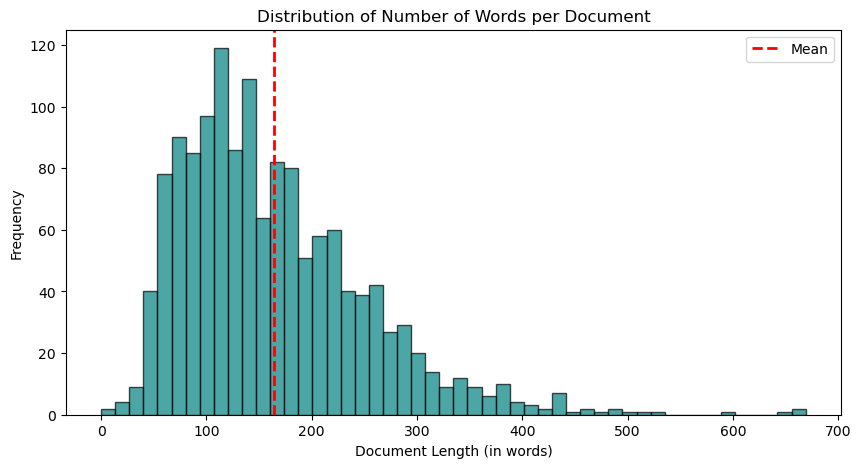

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df_docs['text_length'], bins=50, color='teal', edgecolor='black', alpha=0.7)
plt.axvline(df_docs['text_length'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.title('Distribution of Number of Words per Document')
plt.xlabel('Document Length (in words)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Análise de frequência dos termos

In [9]:
# Junta todas as palavras dos documentos, em minúsculas
all_words = ' '.join(df_docs['text'].dropna()).lower().split()
words_count = Counter(all_words)

# As 20 palavras mais frequentes nos documentos
df_freq = pd.DataFrame(words_count.most_common(20), columns=['Termo', 'Frequência'])
display(df_freq)

,Termo,Frequência
0,the,19408
1,of,12597
2,.,9440
3,and,6085
4,a,5820
5,in,4579
6,to,4507
7,is,4068
8,for,3468
9,are,2415


In [10]:
df_docs['unique_words'] = df_docs['text'].dropna().apply(lambda x: set(str(x).lower().split()))
all_unique_words_per_doc = [word for doc_words in df_docs['unique_words'] for word in doc_words]
df_count = Counter(all_unique_words_per_doc)

df_document_frequency = pd.DataFrame(df_count.most_common(20), columns=['Term', 'DF (Document Count)'])
df_document_frequency['% of Corpus'] = (df_document_frequency['DF (Document Count)'] / len(df_docs)) * 100
print("\nTop 20 Terms with Highest Document Frequency (DF):")
display(df_document_frequency)


Top 20 Terms with Highest Document Frequency (DF):


,Term,DF (Document Count),% of Corpus
0,.,1398,99.857143
1,of,1394,99.571429
2,the,1391,99.357143
3,and,1320,94.285714
4,a,1300,92.857143
5,to,1250,89.285714
6,in,1240,88.571429
7,is,1147,81.928571
8,for,1143,81.642857
9,are,1026,73.285714


## Execução do pré-processamento

In [11]:
# Gera os dados pré-processados nas 4 configurações
print("Building preprocessed data for all 4 configurations...")
preprocessed_data = build_all_configs(df_docs, df_queries)
print("Done!")

Building preprocessed data for all 4 configurations...


Done!


## Resultados do pré-processamento

In [12]:
# Exemplo: saída pré-processada do primeiro documento e da primeira consulta
print("\nExample preprocessing for the first document:")
print(f"Original (raw): {df_docs.iloc[0]['title']} | {df_docs.iloc[0]['text'][:100]}...")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["docs"][0]
    print(f"  {config_name}: {tokens[:10]}... ({len(tokens)} tokens total)")

print("\n" + "="*80)
print("Example preprocessing for the first query:")
print(f"Original (raw): {df_queries.iloc[0]['text']}")
print(f"\nTokenized outputs:")
for config_name in PREPROCESSING_CONFIGS.keys():
    tokens = preprocessed_data[config_name]["queries"][0]
    print(f"  {config_name}: {tokens}")


Example preprocessing for the first document:
Original (raw): experimental investigation of the aerodynamics of a
wing in a slipstream . | experimental investigation of the aerodynamics of a
wing in a slipstream .
  an experimental study o...

Tokenized outputs:
  raw: ['experimental', 'investigation', 'of', 'the', 'aerodynamics', 'of', 'a', 'wing', 'in', 'a']... (149 tokens total)
  stopwords: ['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream']... (83 tokens total)
  stemming: ['experiment', 'investig', 'of', 'the', 'aerodynam', 'of', 'a', 'wing', 'in', 'a']... (149 tokens total)
  stopwords_stemming: ['experiment', 'investig', 'aerodynam', 'wing', 'slipstream', 'experiment', 'investig', 'aerodynam', 'wing', 'slipstream']... (83 tokens total)

Example preprocessing for the first query:
Original (raw): what similarity laws must be obeyed when constructing aeroelastic models
of heated high speed 

In [13]:
# Estatísticas de vocabulário de cada configuração
stats_list = []
for config_name, config_data in preprocessed_data.items():
    stats = vocabulary_stats(config_data["docs"])
    stats["Configuration"] = config_name
    stats_list.append(stats)

df_vocab_stats = pd.DataFrame(stats_list)
df_vocab_stats = df_vocab_stats[["Configuration", "vocabulary_size", "total_tokens", "avg_tokens_per_doc"]]
df_vocab_stats.columns = ["Configuration", "Vocabulary Size", "Total Tokens", "Avg Tokens/Doc"]

print("\nVocabulary Statistics by Configuration:")
display(df_vocab_stats)


Vocabulary Statistics by Configuration:


,Configuration,Vocabulary Size,Total Tokens,Avg Tokens/Doc
0,raw,6985,237586,169.704286
1,stopwords,6867,139013,99.295000
2,stemming,4361,237586,169.704286
3,stopwords_stemming,4251,139013,99.295000


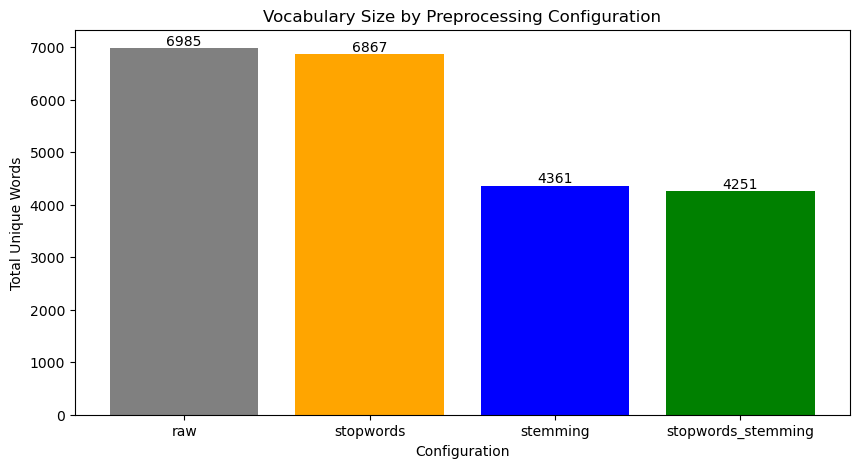

In [14]:
plt.figure(figsize=(10, 5))
bars = plt.bar(df_vocab_stats['Configuration'], df_vocab_stats['Vocabulary Size'], color=['gray', 'orange', 'blue', 'green'])
plt.title('Vocabulary Size by Preprocessing Configuration')
plt.ylabel('Total Unique Words')
plt.xlabel('Configuration')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

plt.show()

## Impacto das configurações no desempenho de recuperação

Comparar as 4 configurações apenas pelo tamanho do vocabulário diz o quanto
cada uma comprime o texto, mas não diz qual delas **recupera melhor**. Abaixo,
cada configuração alimenta os dois modelos do projeto e é avaliada com as
mesmas métricas e os mesmos qrels usados no Caso 4, o que dá base empírica
para a escolha da configuração padrão adotada a partir do Caso 2.

In [15]:
# Avalia as 4 configurações de pré-processamento nos dois modelos.
# Mesmos qrels e mesma função de avaliação do Caso 4, para que os números
# sejam diretamente comparáveis com os dos notebooks seguintes.
from src.vector_model import VectorSpaceModel
from src.bm25 import BM25
from src.metrics import evaluate_model

K = 10
config_rows = []
for config_name, config_data in preprocessed_data.items():
    d_ids, q_ids = config_data["doc_ids"], config_data["query_ids"]
    d_toks, q_toks = config_data["docs"], config_data["queries"]

    for model_name, model in [("Modelo Vetorial", VectorSpaceModel(d_toks)),
                              ("BM25", BM25(d_toks))]:
        rankings = {qid: [d_ids[i] for i, _ in model.rank(tk)]
                    for qid, tk in zip(q_ids, q_toks)}
        ev = evaluate_model(rankings, df_qrels, k=K)
        config_rows.append({
            "Configuração": config_name,
            "Modelo": model_name,
            "MAP": ev["AP"].mean(),
            f"P@{K}": ev[f"precision@{K}"].mean(),
            f"Recall@{K}": ev[f"recall@{K}"].mean(),
            f"NDCG@{K}": ev[f"ndcg@{K}"].mean(),
        })

df_config_eval = pd.DataFrame(config_rows)
print("Desempenho de recuperação por configuração de pré-processamento:")
display(df_config_eval.round(4))

Desempenho de recuperação por configuração de pré-processamento:


,Configuração,Modelo,MAP,P@10,Recall@10,NDCG@10
0,raw,Modelo Vetorial,0.2729,0.2244,0.3664,0.3243
1,raw,BM25,0.2421,0.1889,0.3151,0.2802
2,stopwords,Modelo Vetorial,0.2790,0.2218,0.3629,0.3248
3,stopwords,BM25,0.2863,0.2320,0.3845,0.3405
4,stemming,Modelo Vetorial,0.2944,0.2338,0.3832,0.3406
5,stemming,BM25,0.2620,0.1978,0.3377,0.3000
6,stopwords_stemming,Modelo Vetorial,0.3015,0.2418,0.3987,0.3497
7,stopwords_stemming,BM25,0.3106,0.2342,0.3921,0.3557


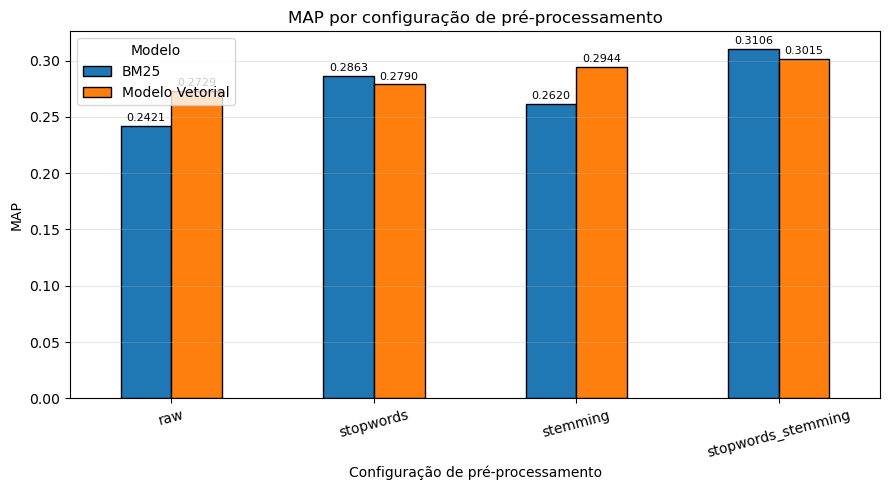

In [16]:
# MAP de cada configuração, lado a lado para os dois modelos
pivot_map = df_config_eval.pivot(index="Configuração", columns="Modelo", values="MAP")
pivot_map = pivot_map.loc[list(PREPROCESSING_CONFIGS.keys())]

ax = pivot_map.plot(kind="bar", figsize=(9, 5), rot=15, edgecolor="black")
ax.set_ylabel("MAP")
ax.set_xlabel("Configuração de pré-processamento")
ax.set_title("MAP por configuração de pré-processamento")
ax.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)
plt.tight_layout()

# Salva a figura em report/figures/ para uso no relatorio. Gerar a figura aqui,
# e nao a mao, garante que ela nunca fique dessincronizada dos resultados.
FIG_DIR = project_root / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "fig3_map_por_configuracao.png", dpi=200, bbox_inches="tight")
plt.show()

### Leitura dos resultados

Os números sustentam a escolha da configuração padrão e revelam uma
assimetria entre os modelos.

**A configuração completa vence para os dois modelos.** `stopwords_stemming`
dá o melhor MAP tanto no Vetorial (0,3015) quanto no BM25 (0,3106), e cada
etapa contribui: partindo do texto cru, o BM25 vai de 0,2421 para 0,2863 só
com a remoção de stopwords, e daí para 0,3106 com o stemming. É essa a
justificativa empírica para fixar essa configuração a partir do Caso 2 — e não
apenas o fato de ela reduzir o vocabulário.

**O BM25 sofre muito mais sem pré-processamento do que o Vetorial.** No texto
cru, o Vetorial (MAP 0,2729) supera o BM25 (0,2421) com folga, e o mesmo
ocorre com stemming isolado (0,2944 contra 0,2620). Só quando as stopwords
saem é que o BM25 passa à frente. A razão está nas duas fórmulas:

- O IDF do BM25 usado aqui, `ln((N-df+0,5)/(df+0,5)) + 1`, fica **negativo**
  para termos presentes em quase toda a coleção. Na configuração crua, 9
  termos têm idf negativo: `of` com −4,368 (df = 1394), `the` com −3,987
  (df = 1391), `and` com −1,824. Uma stopword, portanto, não só deixa de
  ajudar: ela **subtrai** score, e tanto mais quanto mais o documento a repete.
  Como a frequência de "the" num resumo não tem relação nenhuma com
  relevância, isso injeta ruído puro no ranking. É a fraqueza clássica do IDF
  de Robertson, e ela desaparece assim que as stopwords saem: na configuração
  `stopwords_stemming` o menor idf da coleção é +0,917.
- O `TfidfVectorizer` usa `ln((1+N)/(1+df)) + 1`, que é **sempre positivo**:
  na configuração crua o menor idf é 1,004 (`of`) contra 1,691 (`flow`). As
  stopwords recebem um peso pequeno em vez de um peso negativo, e a
  **normalização L2** dilui o que sobra. O Vetorial degrada suavemente; o BM25
  é ativamente penalizado.
- Há ainda um efeito indireto sobre o `b`: com stopwords, os documentos ficam
  cerca de 70% mais longos (169,7 contra 99,3 tokens em média), e como esse
  comprimento entra na normalização do BM25, ele distorce a comparação entre
  documentos que o Vetorial não sofre.

Ou seja, o BM25 é mais dependente de um bom pré-processamento, enquanto o
Modelo Vetorial é mais robusto a texto sujo. As quatro configurações preservam
a ordenação relativa das métricas de conjunto e de posição discutida nos Casos
4 e 5, o que indica que a escolha de pré-processamento e a escolha de modelo
agem sobre o desempenho de forma largamente independente.

In [17]:
# Salva os dados pré-processados em disco, pra reuso nos outros notebooks
output_dir = Path("../data/processed")
output_path = output_dir / "preprocessed_cranfield.pkl"

save_preprocessed(preprocessed_data, output_path)